### Conhecendo o dataset SLCE3

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt


# Carrega o dataset
df = pd.read_csv('SLCE3.csv')

print("Primeiras 5 linhas do DataFrame:")
print(df.head())

print("\nInformações gerais do DataFrame:")
print(df.info())

Primeiras 5 linhas do DataFrame:
         Date     Close      High       Low      Open   Volume
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1738 entries, 0 to 1737
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1738 non-null   object 
 1   Close   1738 non-null   float64
 2   High    1738 non-null   float64
 3   Low     1738 non-null   float64
 4   Open    1738 non-null   float64
 5   Volume  1738 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 81.6+ KB
None


### Tratamento do dataset para valores nulos

In [9]:
# Remove linhas com qualquer valor nulo
df = df.dropna()
print("Após remoção de linhas com valores nulos:")
print(df.info())

Após remoção de linhas com valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1738 entries, 0 to 1737
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1738 non-null   object 
 1   Close   1738 non-null   float64
 2   High    1738 non-null   float64
 3   Low     1738 non-null   float64
 4   Open    1738 non-null   float64
 5   Volume  1738 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 81.6+ KB
None


### Criação das janelas deslizantes de Close futuro

In [10]:
# Criar janelas deslizantes de Close futuro (3, 7, 15 e 30 dias)
df['Close_3d_fut'] = df['Close'].shift(-3)
df['Close_7d_fut'] = df['Close'].shift(-7)  
df['Close_15d_fut'] = df['Close'].shift(-15)
df['Close_30d_fut'] = df['Close'].shift(-30)

print("Janelas deslizantes de Close futuro criadas:")
print("- Close_3d_fut: Close 3 dias no futuro")
print("- Close_7d_fut: Close 7 dias no futuro") 
print("- Close_15d_fut: Close 15 dias no futuro")
print("- Close_30d_fut: Close 30 dias no futuro")

# Remover linhas com valores nulos nas colunas futuras
df_clean = df.dropna(subset=['Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']).copy()

print(f"\nDataset após remoção de nulos: {df_clean.shape[0]} linhas")

Janelas deslizantes de Close futuro criadas:
- Close_3d_fut: Close 3 dias no futuro
- Close_7d_fut: Close 7 dias no futuro
- Close_15d_fut: Close 15 dias no futuro
- Close_30d_fut: Close 30 dias no futuro

Dataset após remoção de nulos: 1708 linhas


### Criação de variáveis dummy e aplicação do OneHotEncoder

In [11]:
# Converte a coluna Date para datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Cria a variável dummy categórica baseada nos períodos identificados
# 0: antes de 2021-05-05 (período inicial)
# 1: entre 2021-05-05 e 2022-02-07 (período de alta volatilidade)
# 2: após 2022-02-07 (período de estabilização)
df_clean['dummy_period'] = 0
df_clean.loc[df_clean['Date'] >= pd.to_datetime('2021-05-05'), 'dummy_period'] = 1
df_clean.loc[df_clean['Date'] >= pd.to_datetime('2022-02-07'), 'dummy_period'] = 2

print(f"Distribuição da variável dummy_period:")
print(df_clean['dummy_period'].value_counts().sort_index())

# Aplicar OneHotEncoder do scikit-learn
encoder = OneHotEncoder(drop='first', sparse_output=False)
dummy_encoded = encoder.fit_transform(df_clean[['dummy_period']])

# Criar DataFrame com as colunas dummy encodadas
dummy_columns = [f'period_{int(cat)}' for cat in encoder.categories_[0][1:]]  # Exclui primeira categoria
dummy_df = pd.DataFrame(dummy_encoded, columns=dummy_columns, index=df_clean.index)

# Concatenar com DataFrame original
df_final = pd.concat([df_clean, dummy_df], axis=1)
print(f"\nColunas criadas pelo OneHotEncoder: {dummy_columns}")
print(f"DataFrame final tem {df_final.shape[0]} linhas e {df_final.shape[1]} colunas")

Distribuição da variável dummy_period:
dummy_period
0    824
1    190
2    694
Name: count, dtype: int64

Colunas criadas pelo OneHotEncoder: ['period_1', 'period_2']
DataFrame final tem 1708 linhas e 13 colunas


### Salvando dataset com alterações feitas

In [12]:
df_final.to_csv('SLCE3_tratado.csv', index=False)

### Modelos sem variáveis dummy (apenas Low, High, Open)

In [13]:
# Definir variáveis independentes (sem dummy)
X_numeric = df_final[['Low', 'High', 'Open']]

# Definir targets (variáveis dependentes)
targets = {
    '3d': df_final['Close_3d_fut'],
    '7d': df_final['Close_7d_fut'], 
    '15d': df_final['Close_15d_fut'],
    '30d': df_final['Close_30d_fut']
}

print("MODELOS SEM VARIÁVEIS DUMMY")
print("=" * 50)

# Dicionário para armazenar modelos treinados
models_numeric = {}

# Treinar modelo para cada janela temporal
for period, y in targets.items():
    # Divisão treino-teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, y, test_size=0.2, random_state=42)
    
    # Treinar modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Fazer predições
    y_pred = model.predict(X_test)
    
    # Calcular métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Armazenar modelo
    models_numeric[period] = {
        'model': model,
        'r2': r2,
        'mae': mae
    }
    
    print(f"\nMODELO {period.upper()} - Predição Close {period} futuro:")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  Intercepto: {model.intercept_:.4f}")
    print(f"  Coeficientes:")
    for i, feature in enumerate(X_numeric.columns):
        print(f"    {feature}: {model.coef_[i]:.4f}")

print(f"\n✓ 4 modelos sem dummy treinados com sucesso!")


MODELOS SEM VARIÁVEIS DUMMY

MODELO 3D - Predição Close 3d futuro:
  R²: 0.9905
  MAE: 0.3742
  Intercepto: 0.1113
  Coeficientes:
    Low: 0.7414
    High: 0.7348
    Open: -0.4835

MODELO 7D - Predição Close 7d futuro:
  R²: 0.9798
  MAE: 0.5687
  Intercepto: 0.2572
  Coeficientes:
    Low: 0.6510
    High: 0.6597
    Open: -0.3277

MODELO 3D - Predição Close 3d futuro:
  R²: 0.9905
  MAE: 0.3742
  Intercepto: 0.1113
  Coeficientes:
    Low: 0.7414
    High: 0.7348
    Open: -0.4835

MODELO 7D - Predição Close 7d futuro:
  R²: 0.9798
  MAE: 0.5687
  Intercepto: 0.2572
  Coeficientes:
    Low: 0.6510
    High: 0.6597
    Open: -0.3277



MODELO 15D - Predição Close 15d futuro:
  R²: 0.9637
  MAE: 0.7477
  Intercepto: 0.5417
  Coeficientes:
    Low: 0.6909
    High: 0.5792
    Open: -0.3023

MODELO 30D - Predição Close 30d futuro:
  R²: 0.9161
  MAE: 1.1824
  Intercepto: 1.0707
  Coeficientes:
    Low: 0.6751
    High: 0.4190
    Open: -0.1552

✓ 4 modelos sem dummy treinados com sucesso!


### Modelos com variáveis dummy (Low, High, Open + period_1, period_2)

In [14]:
# Definir variáveis independentes (com dummy)
X_with_dummy = df_final[['Low', 'High', 'Open'] + dummy_columns]

print("\nMODELOS COM VARIÁVEIS DUMMY")
print("=" * 50)

# Dicionário para armazenar modelos treinados
models_with_dummy = {}

# Treinar modelo para cada janela temporal
for period, y in targets.items():
    # Divisão treino-teste (mesma partição)
    X_train, X_test, y_train, y_test = train_test_split(
        X_with_dummy, y, test_size=0.2, random_state=42)
    
    # Treinar modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Fazer predições
    y_pred = model.predict(X_test)
    
    # Calcular métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Armazenar modelo
    models_with_dummy[period] = {
        'model': model,
        'r2': r2,
        'mae': mae
    }
    
    print(f"\nMODELO {period.upper()} - Predição Close {period} futuro:")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  Intercepto: {model.intercept_:.4f}")
    print(f"  Coeficientes:")
    for i, feature in enumerate(X_with_dummy.columns):
        print(f"    {feature}: {model.coef_[i]:.4f}")



MODELOS COM VARIÁVEIS DUMMY

MODELO 3D - Predição Close 3d futuro:
  R²: 0.9905
  MAE: 0.3740
  Intercepto: 0.1720
  Coeficientes:
    Low: 0.7199
    High: 0.7503
    Open: -0.4871
    period_1: 0.0822
    period_2: 0.1092

MODELO 7D - Predição Close 7d futuro:
  R²: 0.9798
  MAE: 0.5711
  Intercepto: 0.3499
  Coeficientes:
    Low: 0.6019
    High: 0.6958
    Open: -0.3296
    period_1: 0.0821
    period_2: 0.1721

MODELO 15D - Predição Close 15d futuro:
  R²: 0.9636
  MAE: 0.7502
  Intercepto: 0.8348
  Coeficientes:
    Low: 0.5598
    High: 0.6747
    Open: -0.3134
    period_1: 0.3243
    period_2: 0.5362

MODELO 30D - Predição Close 30d futuro:
  R²: 0.9170
  MAE: 1.1909
  Intercepto: 1.5875
  Coeficientes:
    Low: 0.5090
    High: 0.5375
    Open: -0.1888
    period_1: 0.7453
    period_2: 0.9247

MODELO 3D - Predição Close 3d futuro:
  R²: 0.9905
  MAE: 0.3740
  Intercepto: 0.1720
  Coeficientes:
    Low: 0.7199
    High: 0.7503
    Open: -0.4871
    period_1: 0.0822
    peri

In [15]:
print(f"\n✓ 4 modelos com dummy treinados com sucesso!")

print("\n" + "=" * 60)
print("RESUMO: 8 MODELOS TREINADOS")
print("=" * 60)
print("✓ 4 modelos sem variáveis dummy (Low, High, Open)")
print("✓ 4 modelos com variáveis dummy (Low, High, Open + period_1, period_2)")
print("✓ Janelas temporais: 3d, 7d, 15d, 30d")
print("✓ Métricas calculadas: R² e MAE")
print("=" * 60)


✓ 4 modelos com dummy treinados com sucesso!

RESUMO: 8 MODELOS TREINADOS
✓ 4 modelos sem variáveis dummy (Low, High, Open)
✓ 4 modelos com variáveis dummy (Low, High, Open + period_1, period_2)
✓ Janelas temporais: 3d, 7d, 15d, 30d
✓ Métricas calculadas: R² e MAE


# Analises Graficas

### Gráficos de série temporal - Modelos sem variáveis dummy

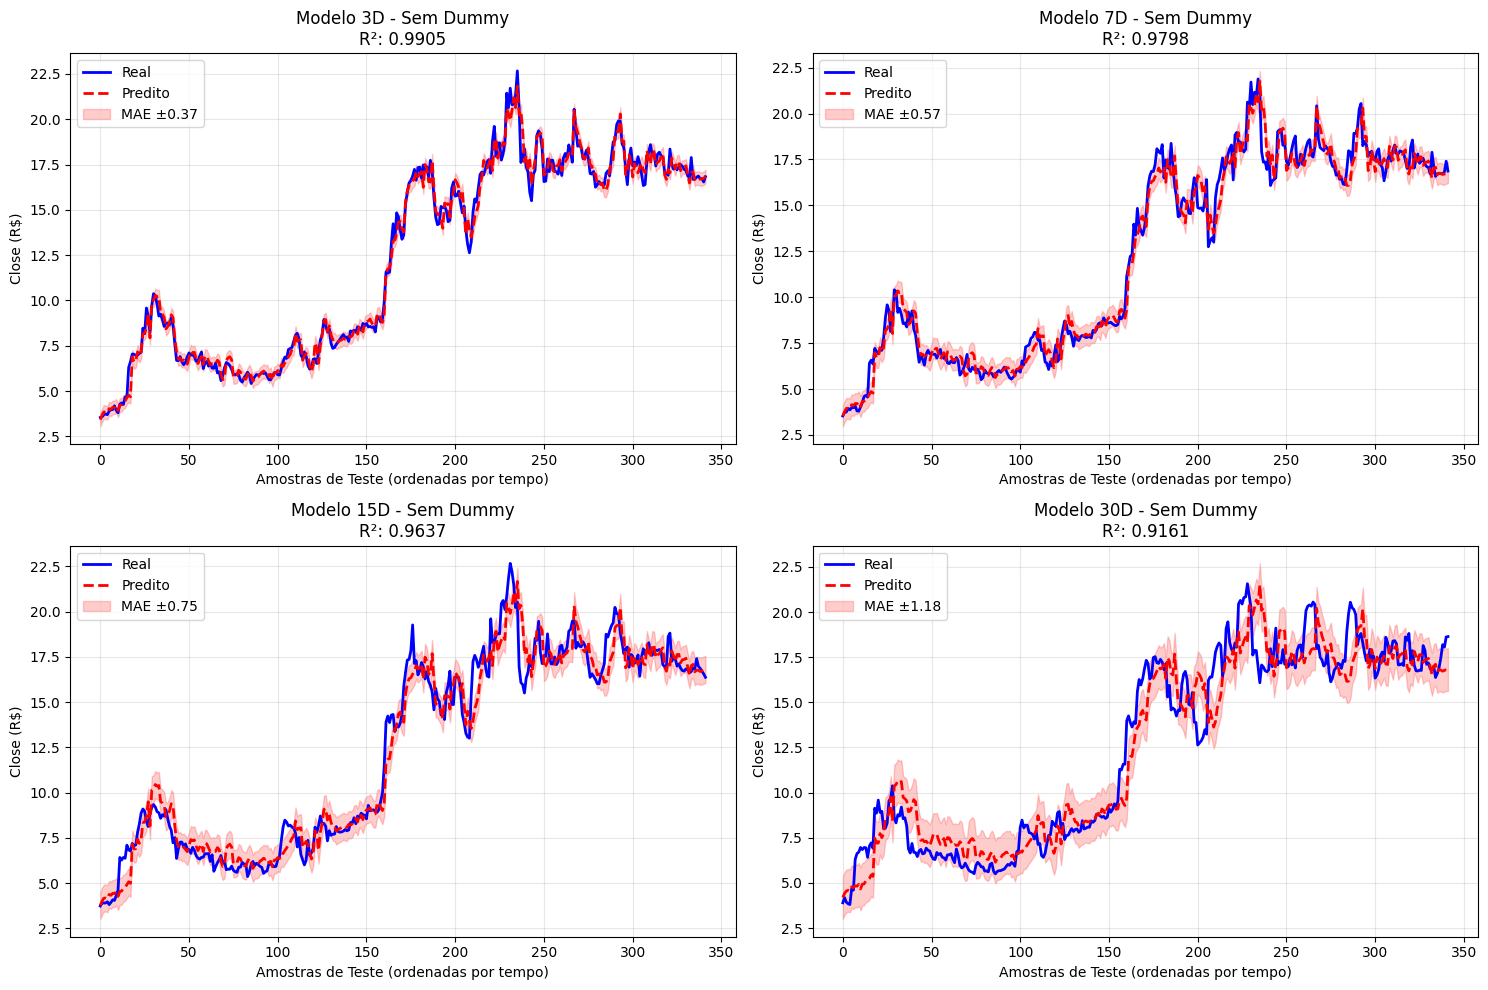

In [16]:
# Gráficos para modelos sem variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_numeric.items()):
    # Obter dados de teste para visualização
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, targets[period], test_size=0.2, random_state=42)
    
    # Predições no conjunto de teste
    y_pred = model_data['model'].predict(X_test)
    mae = model_data['mae']
    
    # Ordenar por índice para visualização temporal
    test_indices = X_test.index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    
    y_test_sorted = y_test.iloc[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(y_test_sorted)), y_test_sorted, 'b-', label='Real', linewidth=2)
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'r--', label='Predito', linewidth=2)
    
    # Adicionar túnel do MAE
    ax.fill_between(range(len(y_pred_sorted)), 
                    y_pred_sorted - mae, 
                    y_pred_sorted + mae, 
                    alpha=0.2, color='red', label=f'MAE ±{mae:.2f}')
    
    ax.set_title(f'Modelo {period.upper()} - Sem Dummy\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Amostras de Teste (ordenadas por tempo)')
    ax.set_ylabel('Close (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graficos_modelos_sem_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráficos de série temporal - Modelos com variáveis dummy

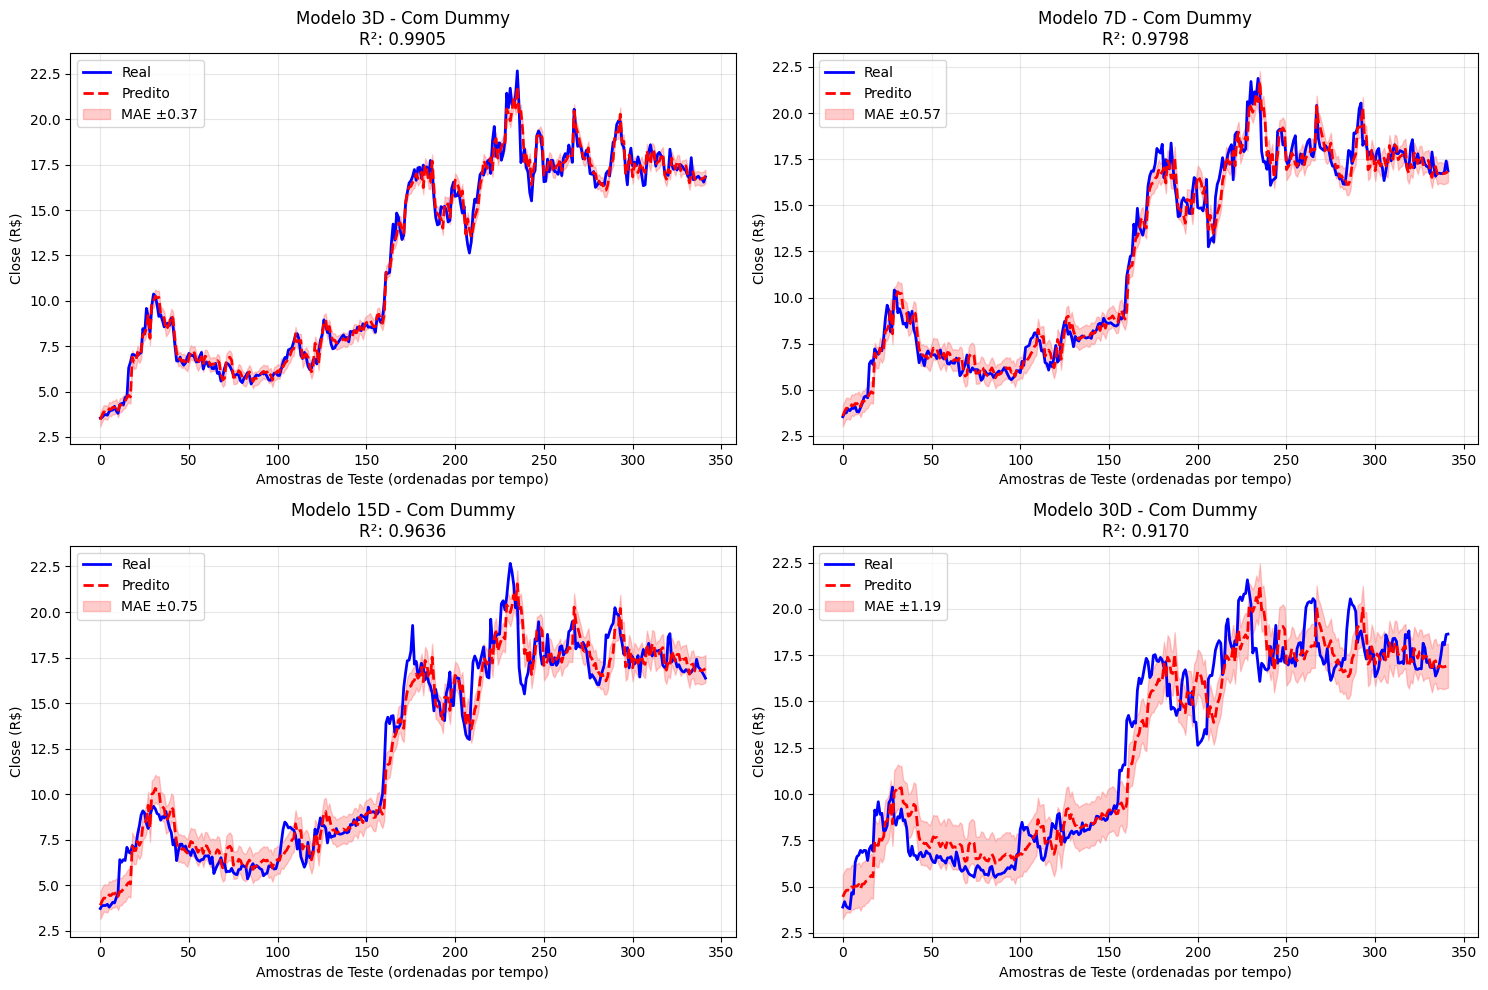

In [17]:
# Gráficos para modelos com variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_with_dummy.items()):
    # Obter dados de teste para visualização
    X_train, X_test, y_train, y_test = train_test_split(
        X_with_dummy, targets[period], test_size=0.2, random_state=42)
    
    # Predições no conjunto de teste
    y_pred = model_data['model'].predict(X_test)
    mae = model_data['mae']
    
    # Ordenar por índice para visualização temporal
    test_indices = X_test.index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    
    y_test_sorted = y_test.iloc[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(y_test_sorted)), y_test_sorted, 'b-', label='Real', linewidth=2)
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'r--', label='Predito', linewidth=2)
    
    # Adicionar túnel do MAE
    ax.fill_between(range(len(y_pred_sorted)), 
                    y_pred_sorted - mae, 
                    y_pred_sorted + mae, 
                    alpha=0.2, color='red', label=f'MAE ±{mae:.2f}')
    
    ax.set_title(f'Modelo {period.upper()} - Com Dummy\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Amostras de Teste (ordenadas por tempo)')
    ax.set_ylabel('Close (R$)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graficos_modelos_com_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráficos de resíduos - Modelos sem variáveis dummy

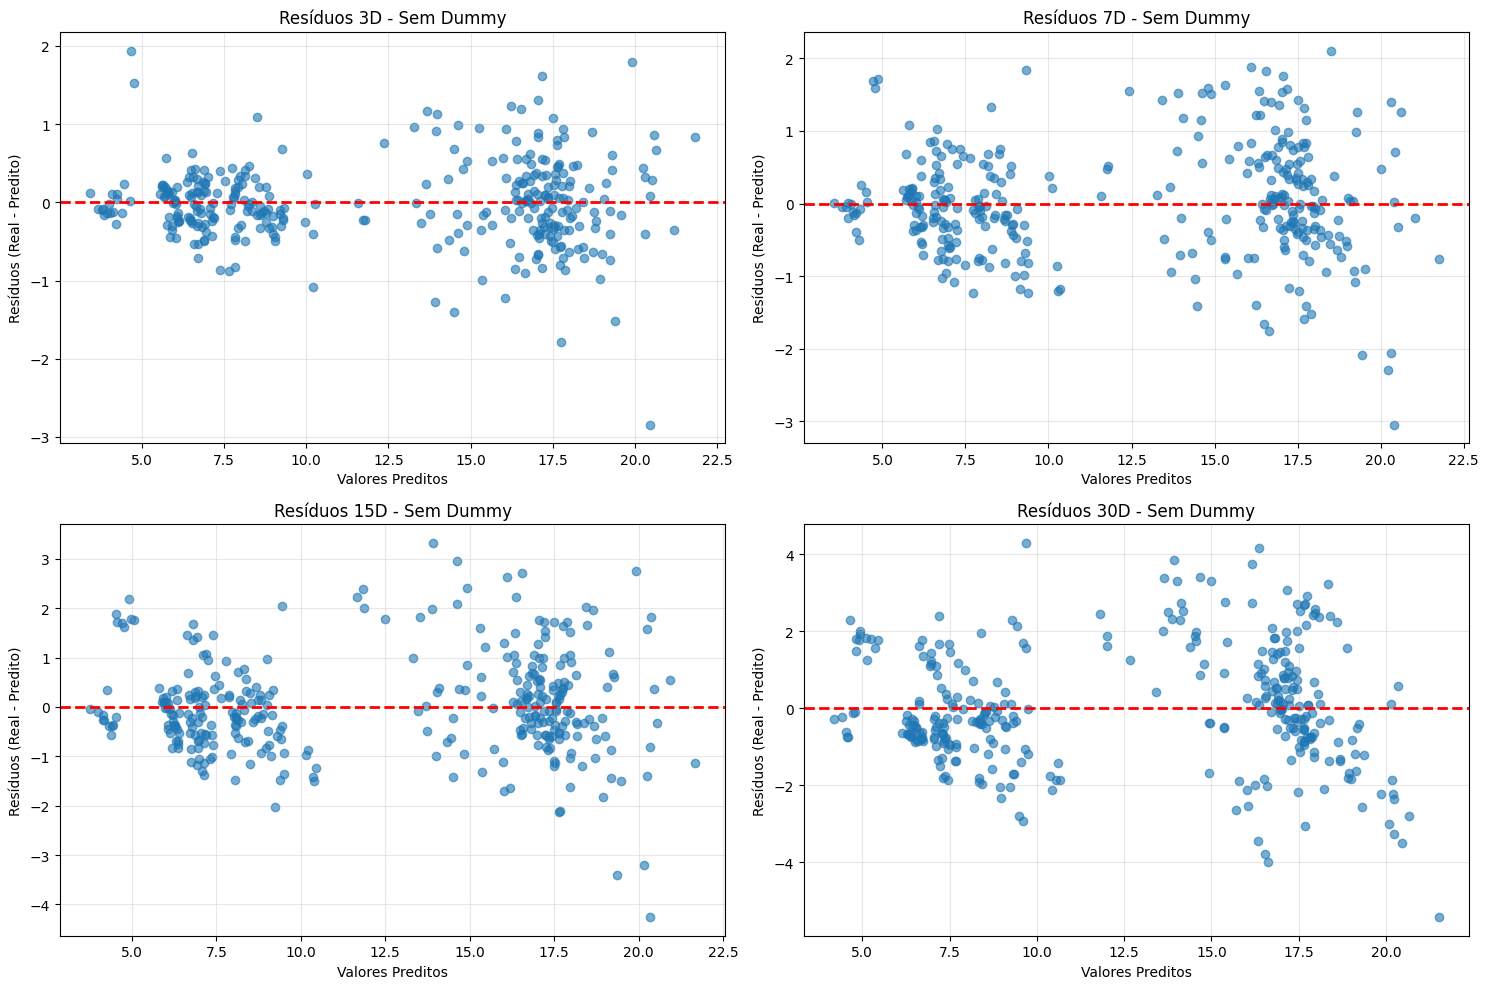

In [18]:
# Gráficos de resíduos para modelos sem variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_numeric.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, targets[period], test_size=0.2, random_state=42)
    
    # Predições e resíduos
    y_pred = model_data['model'].predict(X_test)
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_pred, residuos, alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos {period.upper()} - Sem Dummy')
    ax.set_xlabel('Valores Preditos')
    ax.set_ylabel('Resíduos (Real - Predito)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuos_modelos_sem_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráficos de resíduos - Modelos com variáveis dummy

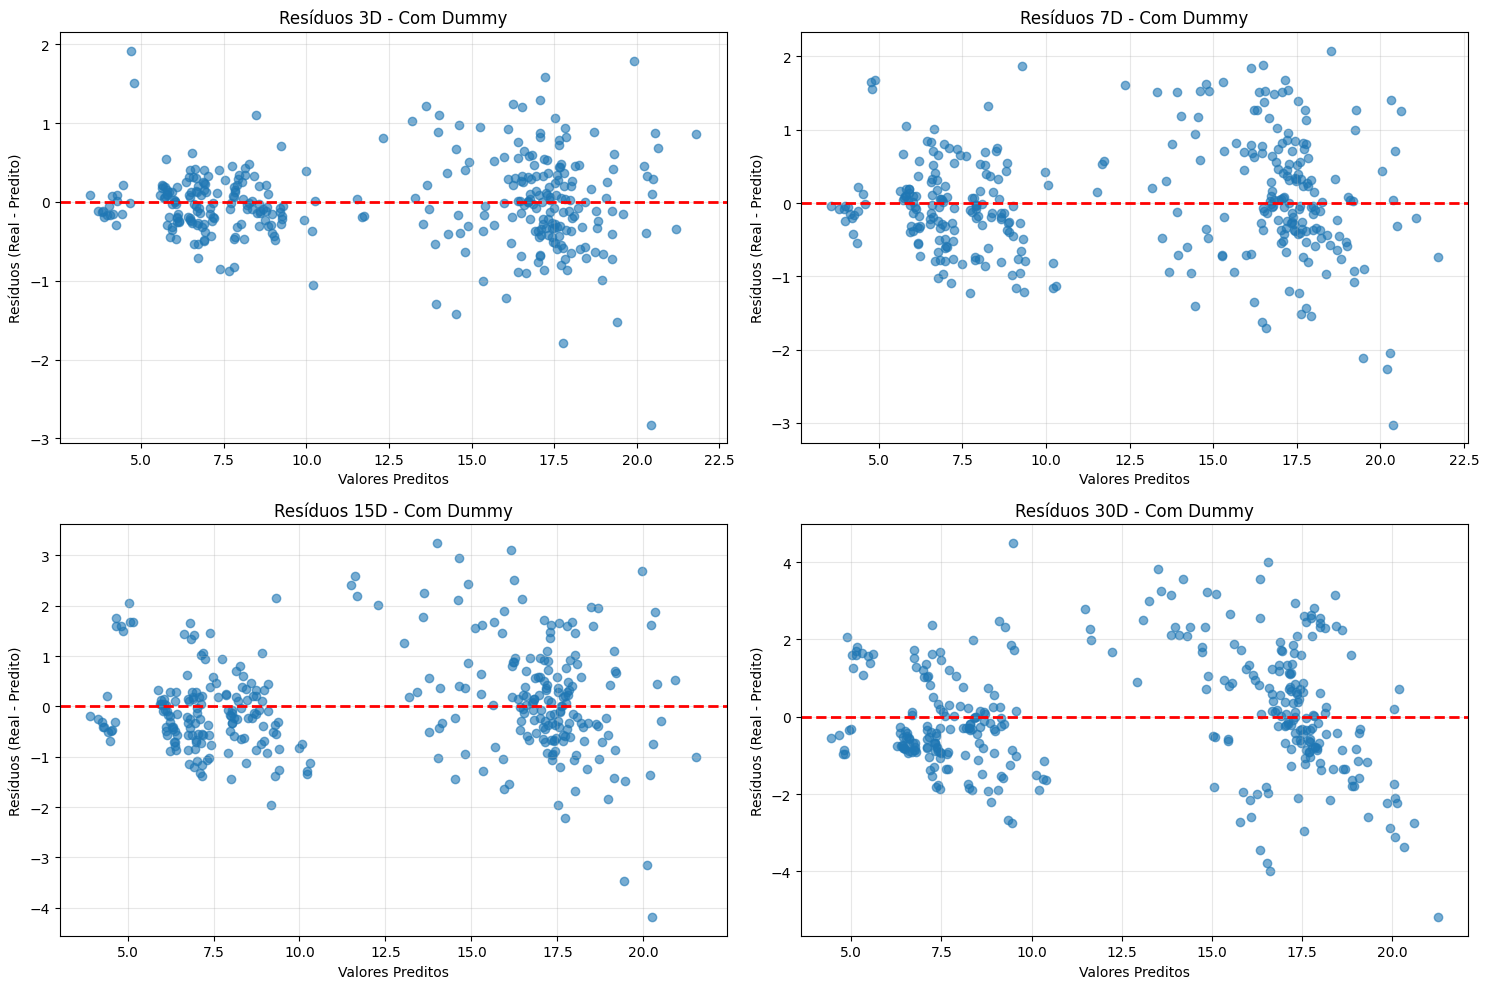

In [19]:
# Gráficos de resíduos para modelos com variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_with_dummy.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_with_dummy, targets[period], test_size=0.2, random_state=42)
    
    # Predições e resíduos
    y_pred = model_data['model'].predict(X_test)
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_pred, residuos, alpha=0.6)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos {period.upper()} - Com Dummy')
    ax.set_xlabel('Valores Preditos')
    ax.set_ylabel('Resíduos (Real - Predito)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuos_modelos_com_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráficos Real vs Predito - Modelos sem variáveis dummy

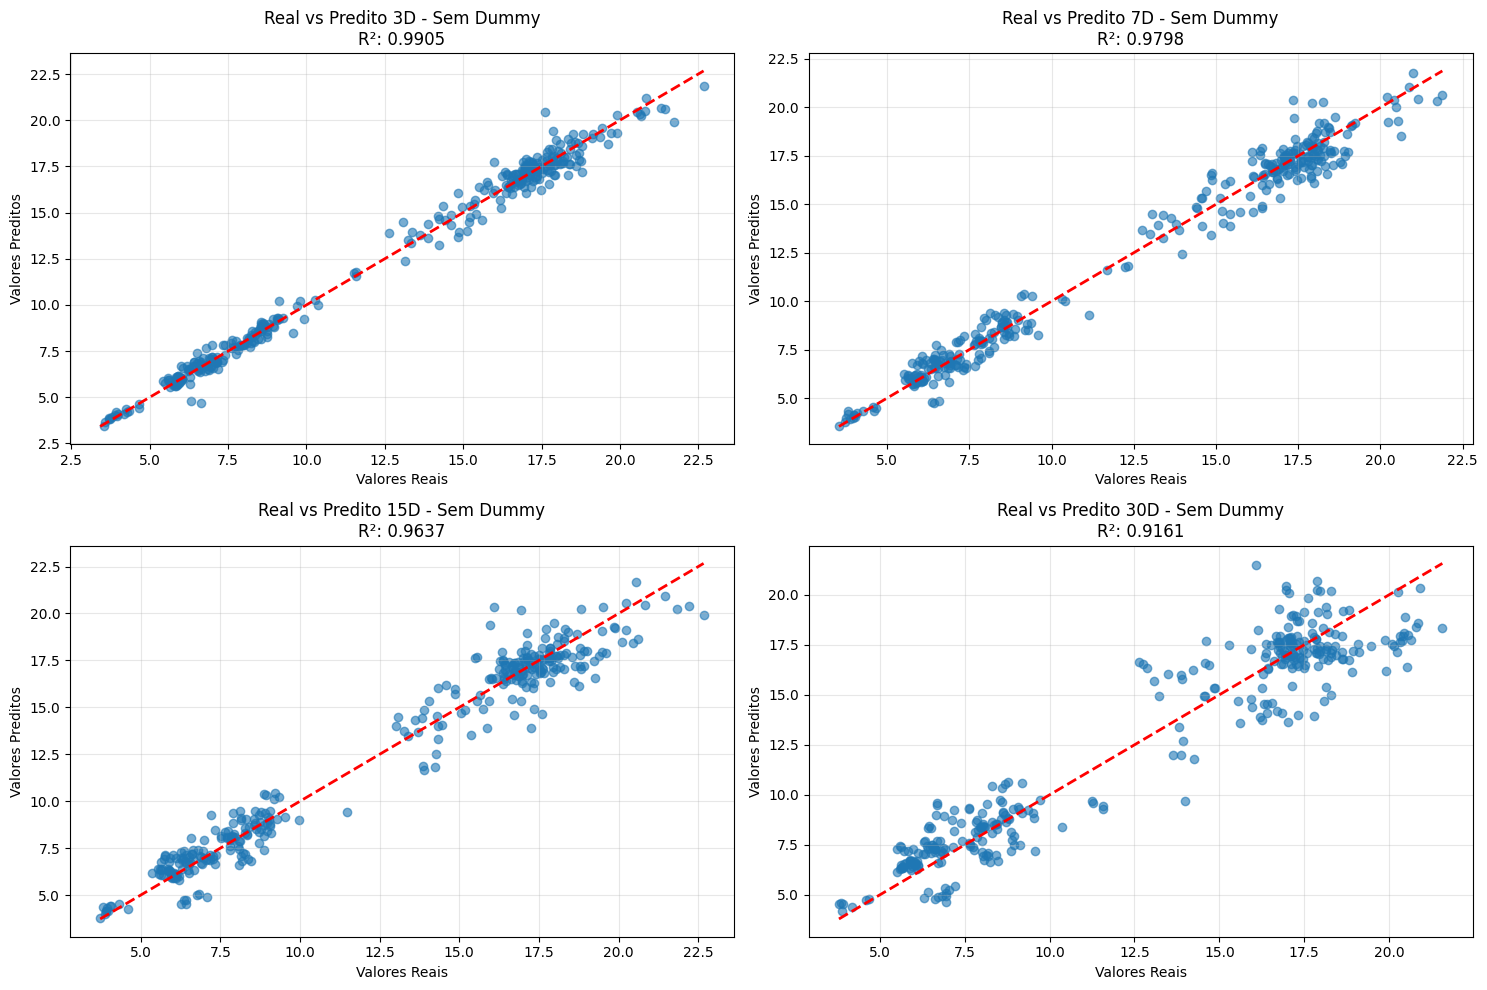

In [20]:
# Gráficos Real vs Predito para modelos sem variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_numeric.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, targets[period], test_size=0.2, random_state=42)
    
    # Predições
    y_pred = model_data['model'].predict(X_test)
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6)
    
    # Linha diagonal y=x (predição perfeita)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_title(f'Real vs Predito {period.upper()} - Sem Dummy\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Valores Reais')
    ax.set_ylabel('Valores Preditos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('real_vs_predito_sem_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráficos Real vs Predito - Modelos com variáveis dummy

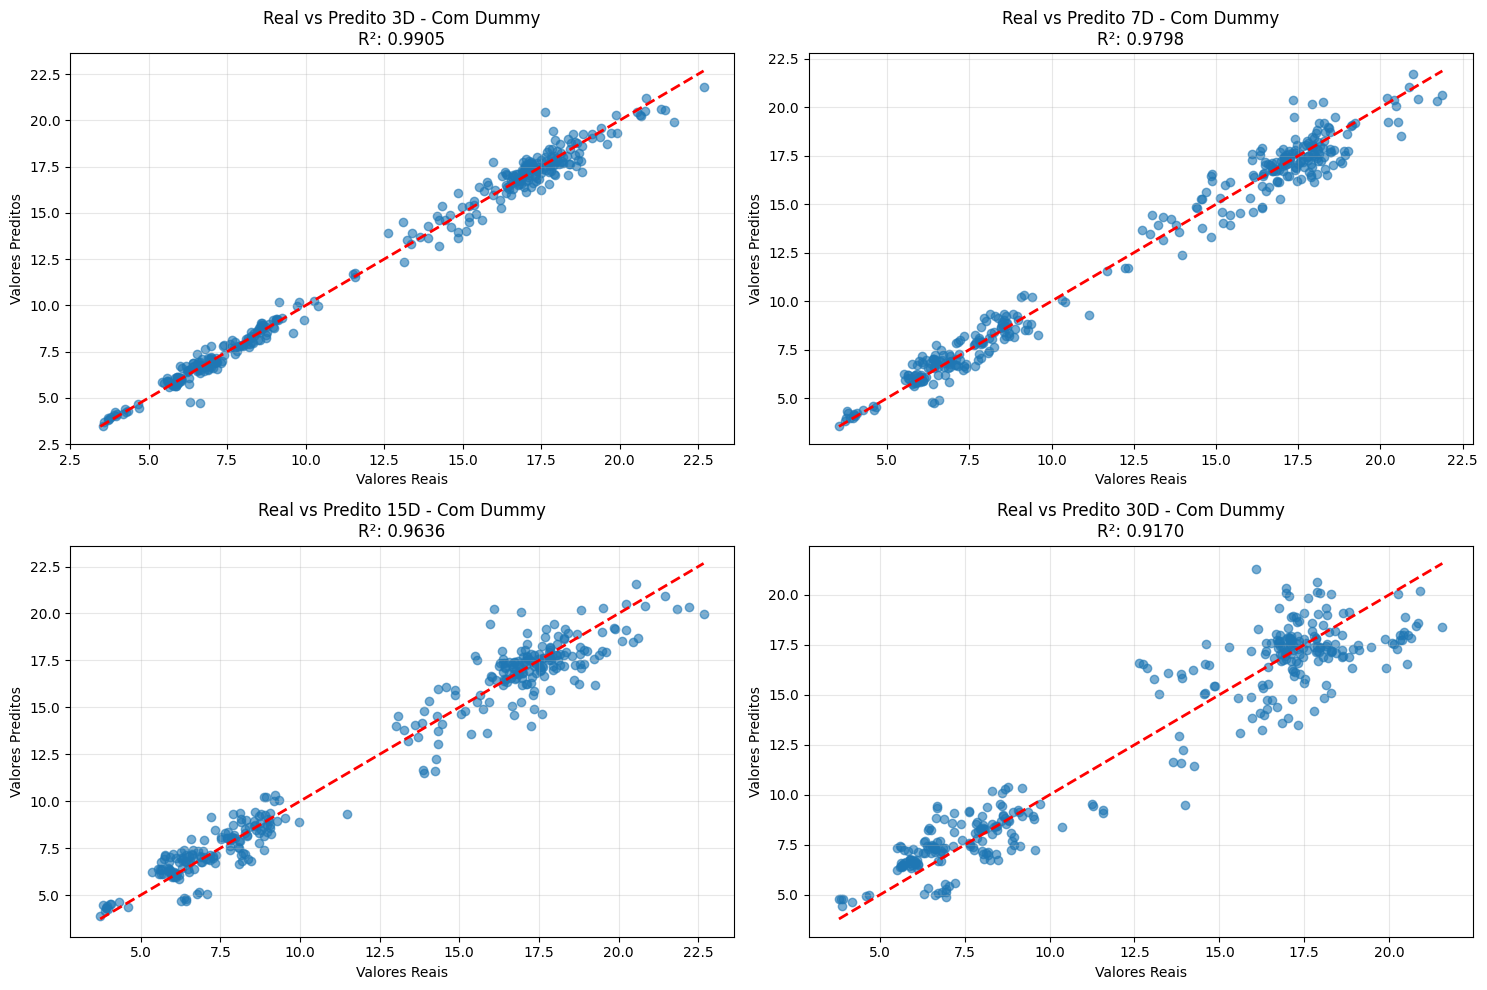

In [21]:
# Gráficos Real vs Predito para modelos com variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_with_dummy.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_with_dummy, targets[period], test_size=0.2, random_state=42)
    
    # Predições
    y_pred = model_data['model'].predict(X_test)
    
    # Plotar
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6)
    
    # Linha diagonal y=x (predição perfeita)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_title(f'Real vs Predito {period.upper()} - Com Dummy\nR²: {model_data["r2"]:.4f}')
    ax.set_xlabel('Valores Reais')
    ax.set_ylabel('Valores Preditos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('real_vs_predito_com_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Comparação das Métricas (R² e MAE)

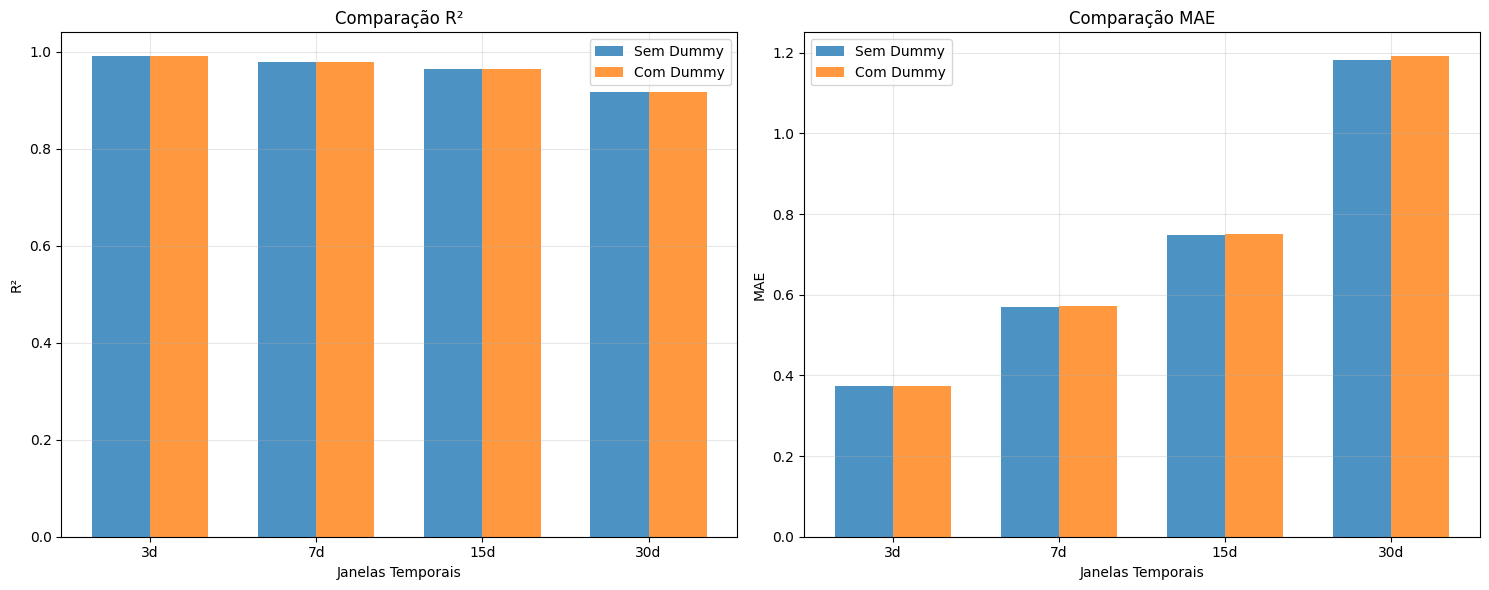

In [22]:
# Comparação das métricas entre modelos
periods = ['3d', '7d', '15d', '30d']
r2_sem_dummy = [models_numeric[period]['r2'] for period in periods]
mae_sem_dummy = [models_numeric[period]['mae'] for period in periods]
r2_com_dummy = [models_with_dummy[period]['r2'] for period in periods]
mae_com_dummy = [models_with_dummy[period]['mae'] for period in periods]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico R²
x = np.arange(len(periods))
width = 0.35

ax1.bar(x - width/2, r2_sem_dummy, width, label='Sem Dummy', alpha=0.8)
ax1.bar(x + width/2, r2_com_dummy, width, label='Com Dummy', alpha=0.8)
ax1.set_xlabel('Janelas Temporais')
ax1.set_ylabel('R²')
ax1.set_title('Comparação R²')
ax1.set_xticks(x)
ax1.set_xticklabels(periods)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico MAE
ax2.bar(x - width/2, mae_sem_dummy, width, label='Sem Dummy', alpha=0.8)
ax2.bar(x + width/2, mae_com_dummy, width, label='Com Dummy', alpha=0.8)
ax2.set_xlabel('Janelas Temporais')
ax2.set_ylabel('MAE')
ax2.set_title('Comparação MAE')
ax2.set_xticks(x)
ax2.set_xticklabels(periods)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparacao_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

### Histogramas dos Resíduos - Modelos sem variáveis dummy

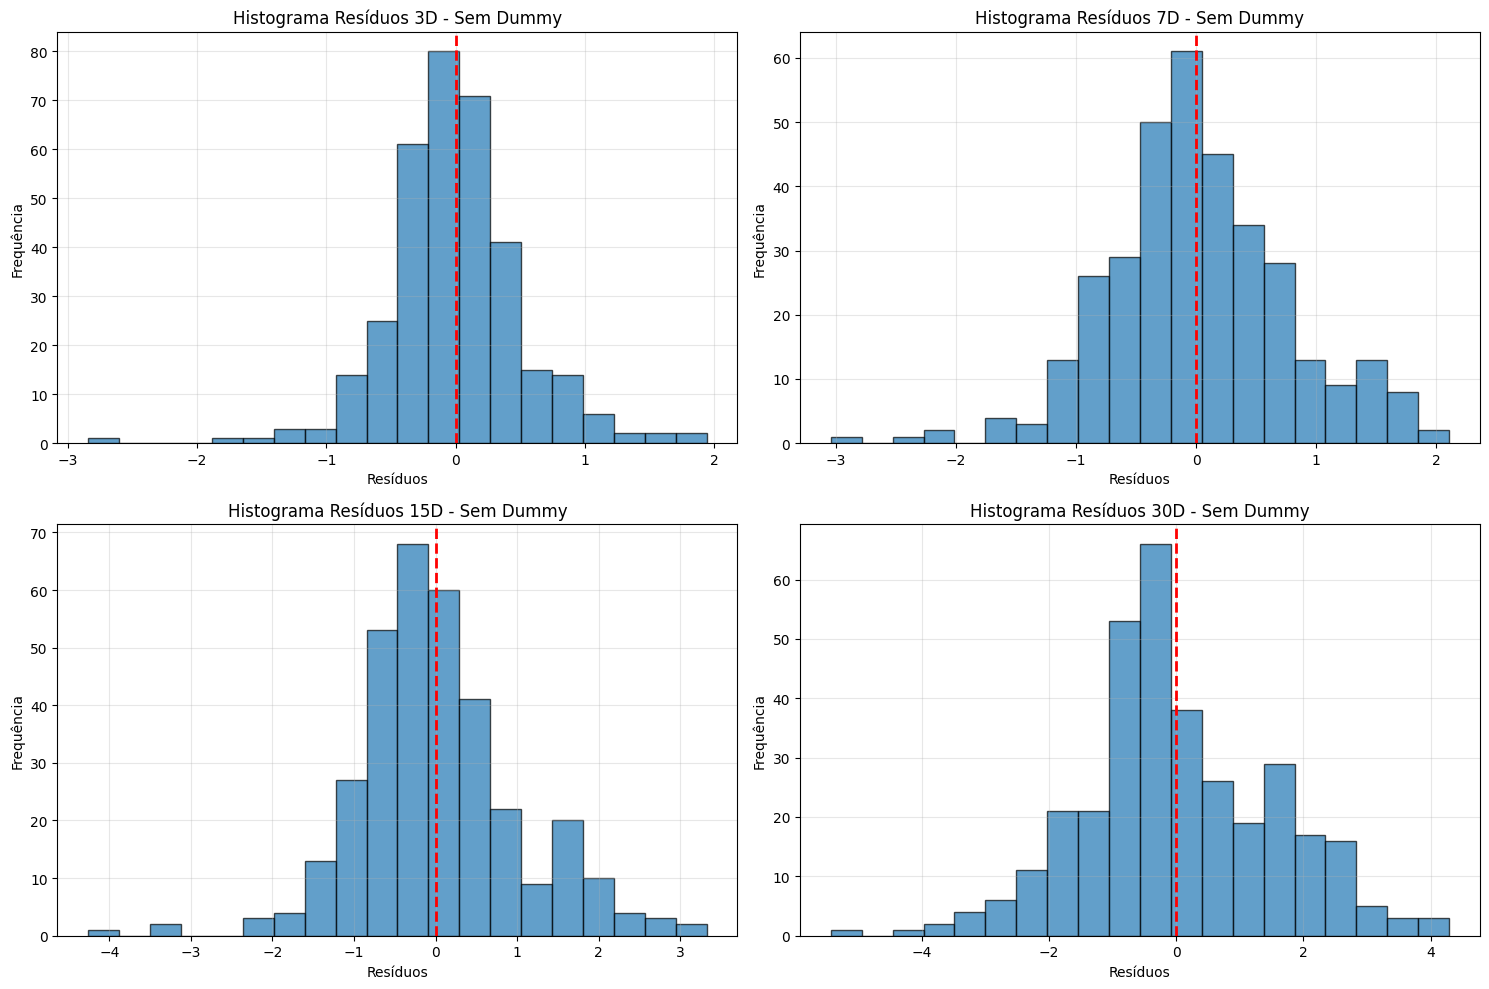

In [23]:
# Histogramas dos resíduos para modelos sem variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_numeric.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, targets[period], test_size=0.2, random_state=42)
    
    # Predições e resíduos
    y_pred = model_data['model'].predict(X_test)
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.hist(residuos, bins=20, alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Histograma Resíduos {period.upper()} - Sem Dummy')
    ax.set_xlabel('Resíduos')
    ax.set_ylabel('Frequência')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('histograma_residuos_sem_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Histogramas dos Resíduos - Modelos com variáveis dummy

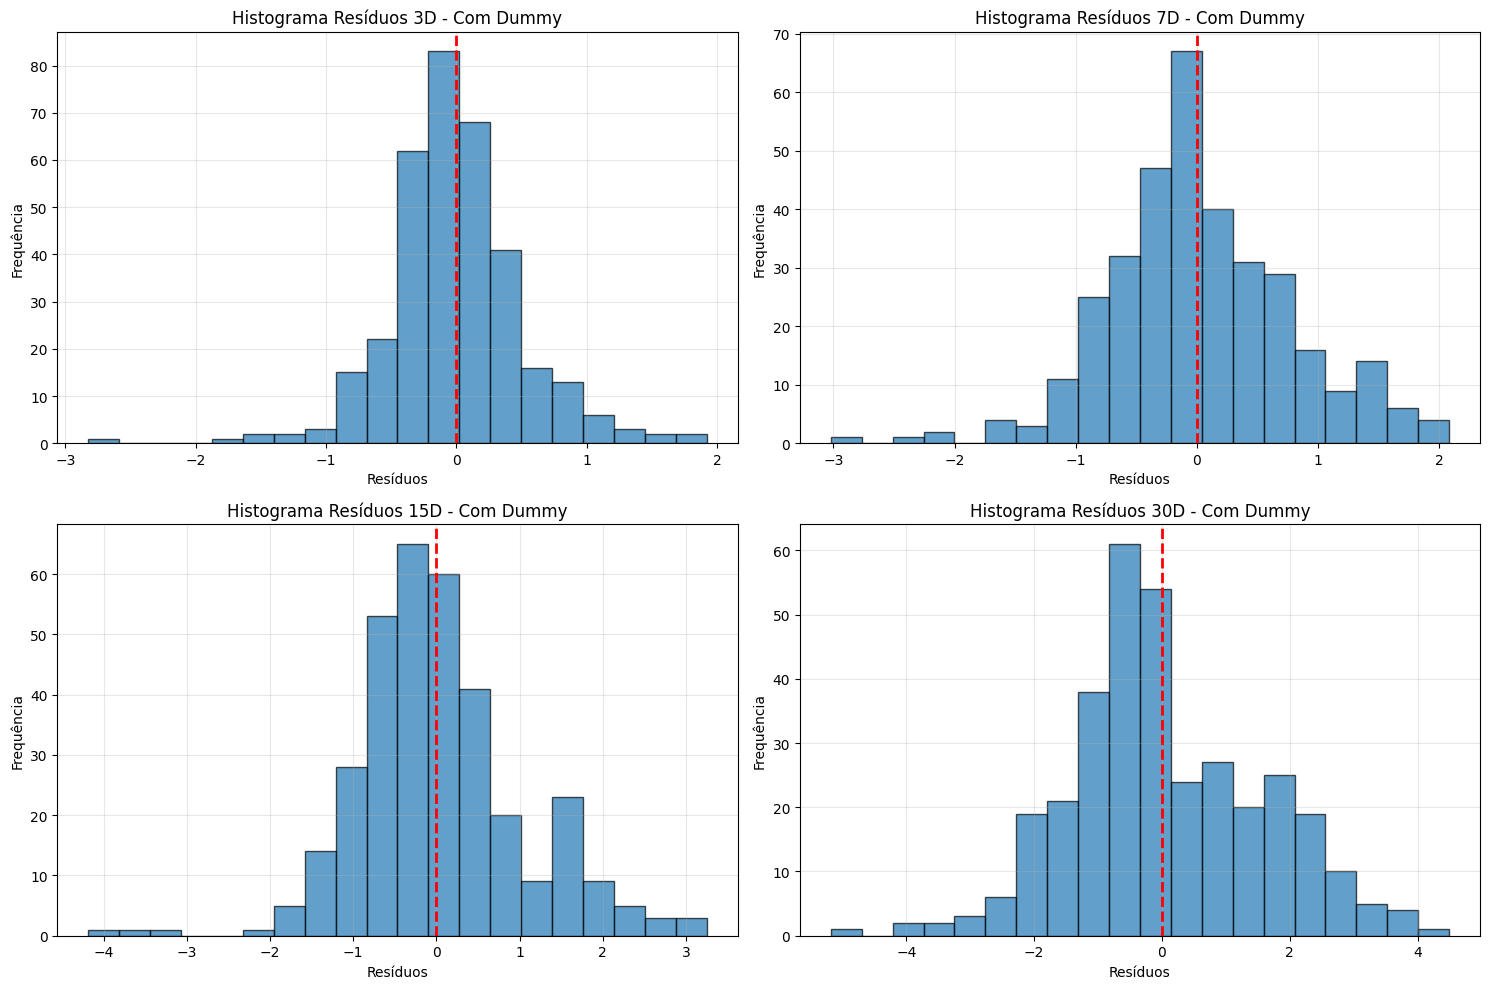

In [24]:
# Histogramas dos resíduos para modelos com variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_with_dummy.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_with_dummy, targets[period], test_size=0.2, random_state=42)
    
    # Predições e resíduos
    y_pred = model_data['model'].predict(X_test)
    residuos = y_test - y_pred
    
    # Plotar
    ax = axes[idx]
    ax.hist(residuos, bins=20, alpha=0.7, edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Histograma Resíduos {period.upper()} - Com Dummy')
    ax.set_xlabel('Resíduos')
    ax.set_ylabel('Frequência')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('histograma_residuos_com_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Resíduos vs Ordem Temporal - Modelos sem variáveis dummy

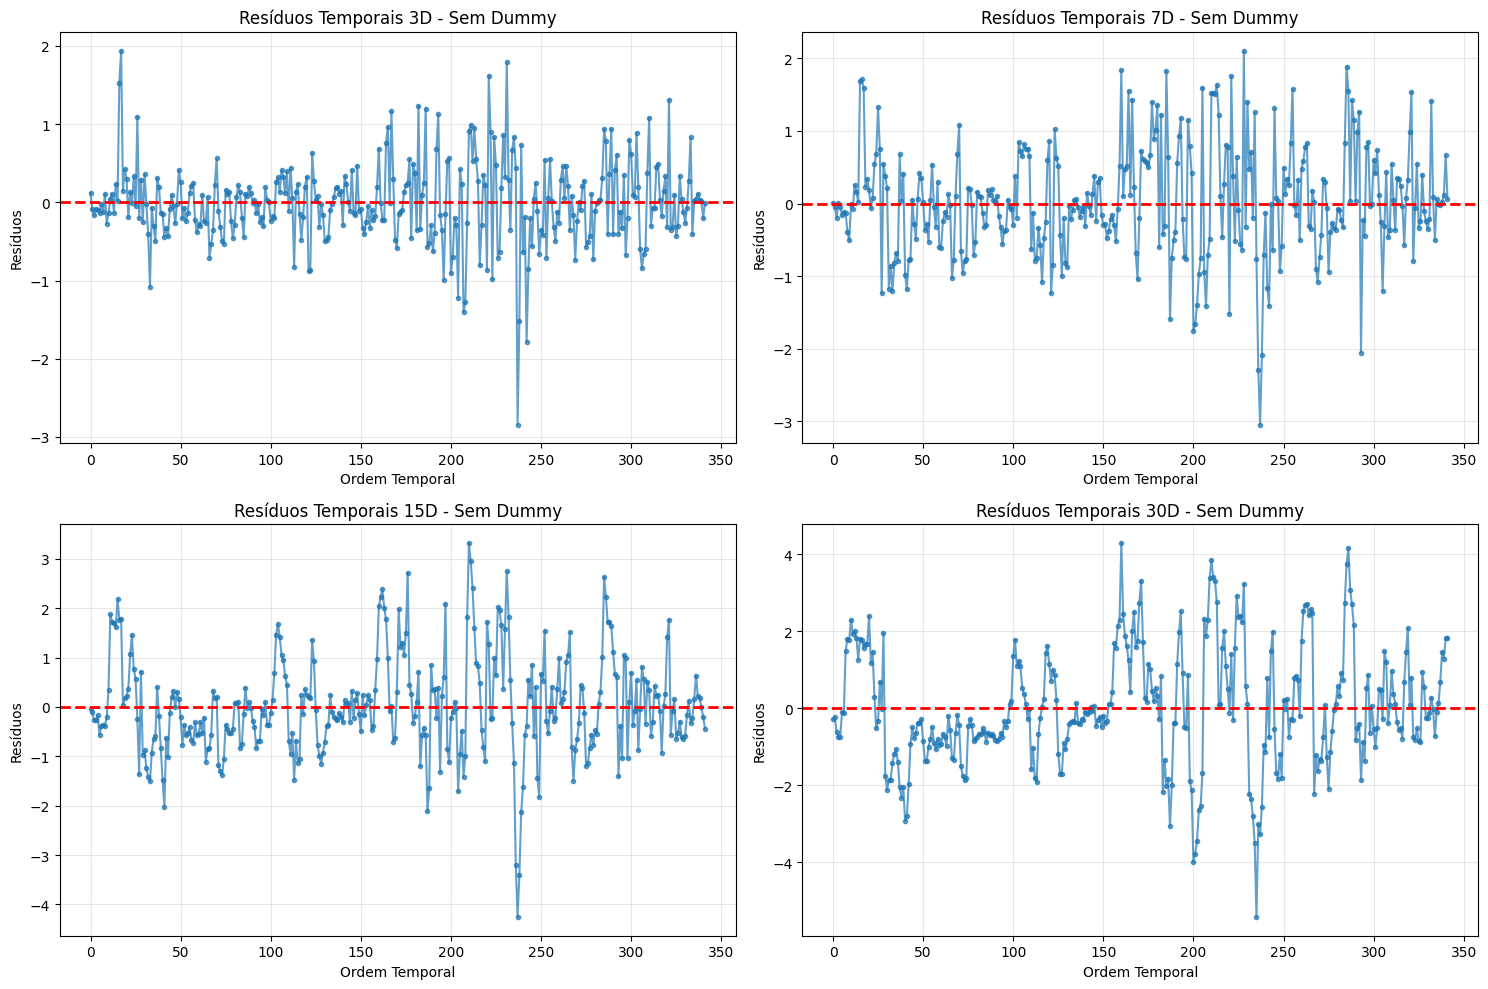

In [25]:
# Resíduos vs Ordem Temporal para modelos sem variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_numeric.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, targets[period], test_size=0.2, random_state=42)
    
    # Predições e resíduos
    y_pred = model_data['model'].predict(X_test)
    residuos = y_test - y_pred
    
    # Ordenar por índice temporal
    test_indices = X_test.index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    residuos_sorted = residuos.iloc[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(residuos_sorted)), residuos_sorted, 'o-', markersize=3, alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos Temporais {period.upper()} - Sem Dummy')
    ax.set_xlabel('Ordem Temporal')
    ax.set_ylabel('Resíduos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuos_temporais_sem_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Resíduos vs Ordem Temporal - Modelos com variáveis dummy

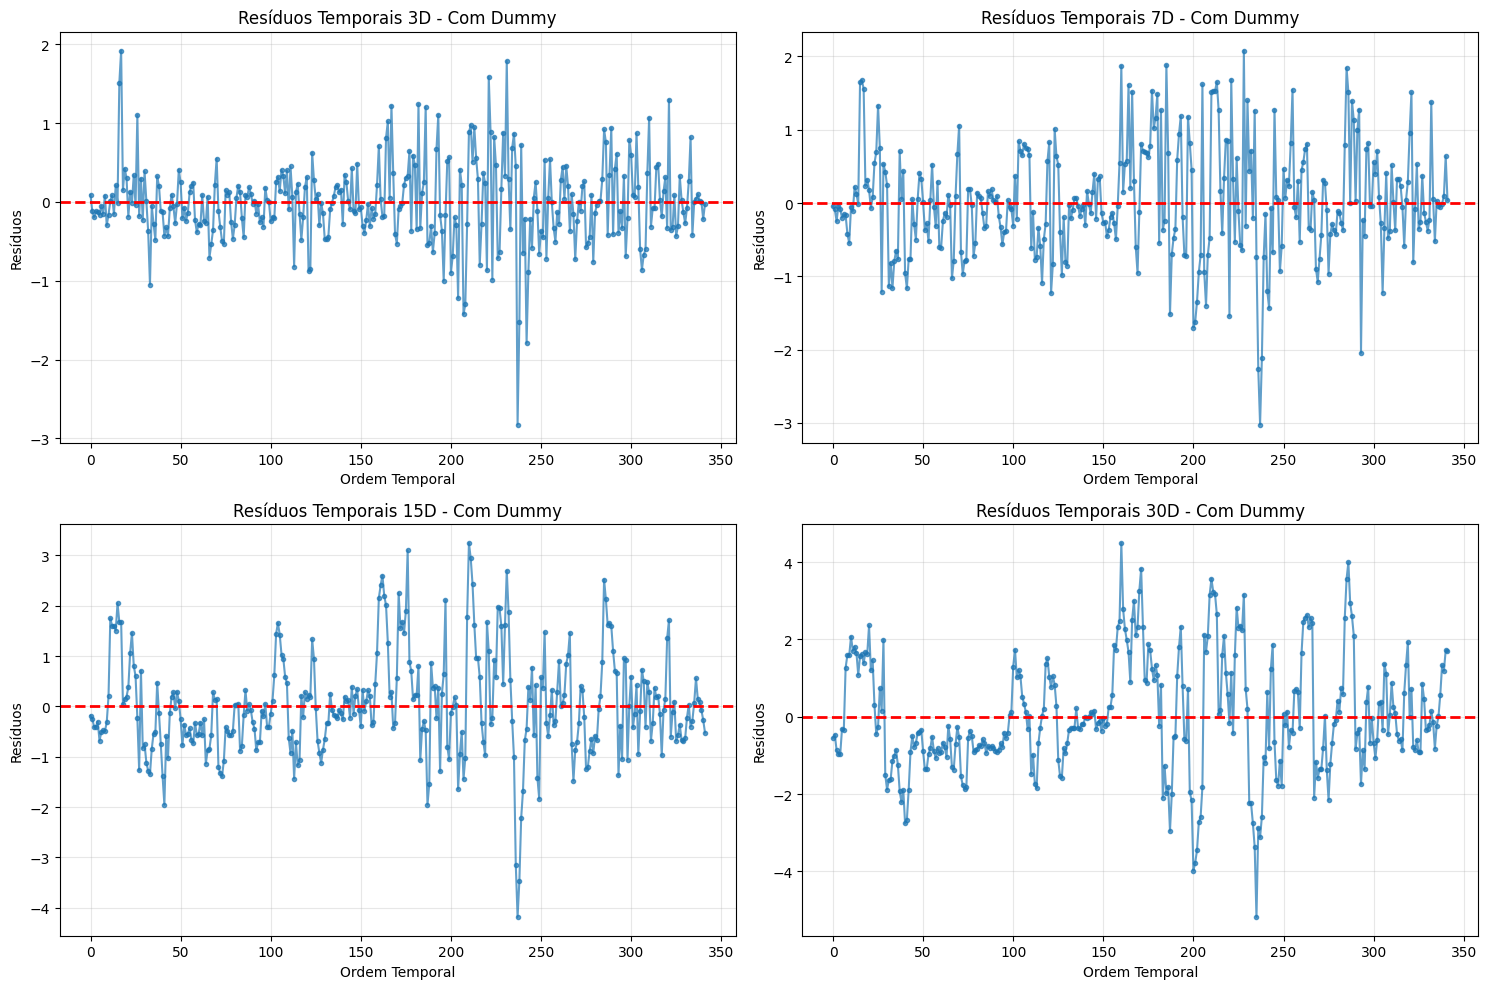

In [26]:
# Resíduos vs Ordem Temporal para modelos com variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_with_dummy.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_with_dummy, targets[period], test_size=0.2, random_state=42)
    
    # Predições e resíduos
    y_pred = model_data['model'].predict(X_test)
    residuos = y_test - y_pred
    
    # Ordenar por índice temporal
    test_indices = X_test.index
    sorted_indices = sorted(range(len(test_indices)), key=lambda i: test_indices[i])
    residuos_sorted = residuos.iloc[sorted_indices]
    
    # Plotar
    ax = axes[idx]
    ax.plot(range(len(residuos_sorted)), residuos_sorted, 'o-', markersize=3, alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'Resíduos Temporais {period.upper()} - Com Dummy')
    ax.set_xlabel('Ordem Temporal')
    ax.set_ylabel('Resíduos')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuos_temporais_com_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráfico de Dispersão com Linha de Regressão, Intervalo de Confiança e Intervalo de Predição

#### Sem uso de Dummy

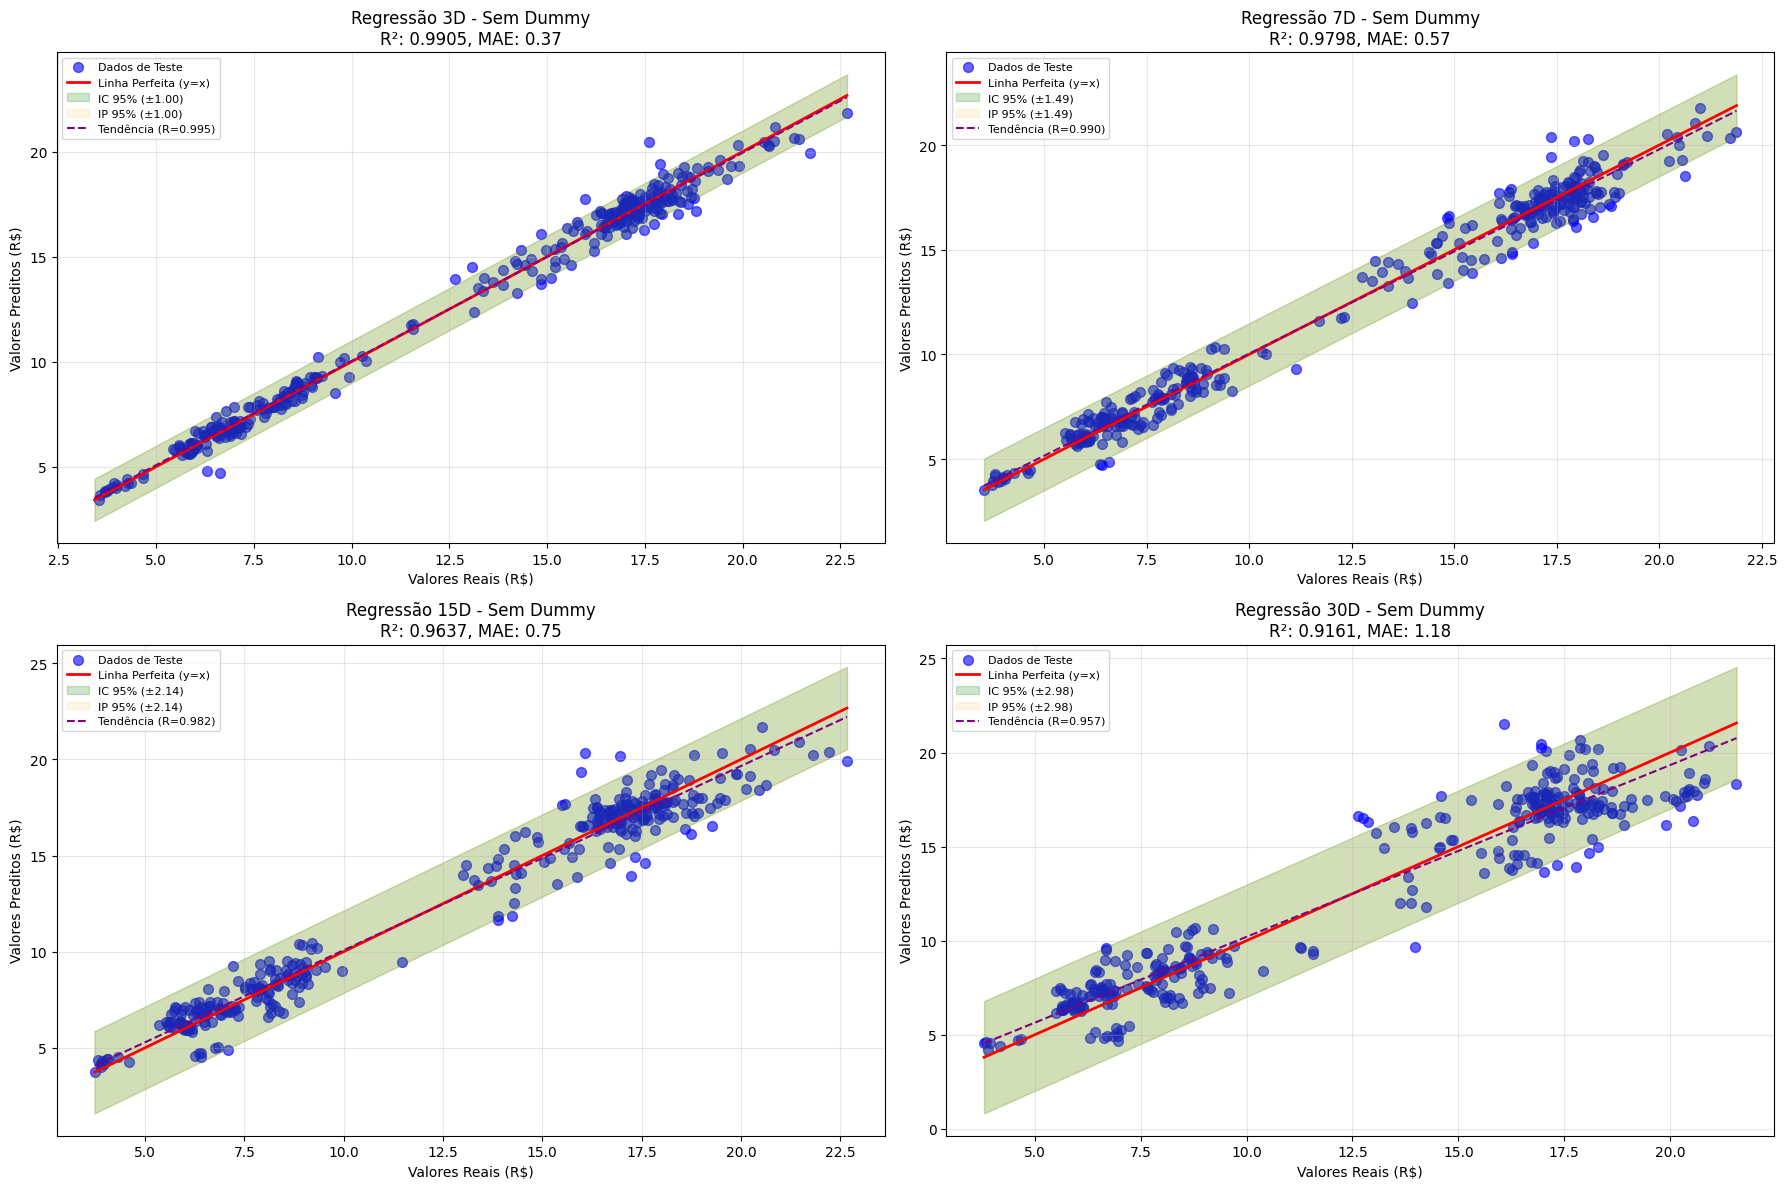

Gráficos de dispersão com IC e IP (modelos sem dummy) gerados com sucesso!


In [27]:
from scipy import stats
from sklearn.metrics import mean_squared_error
import seaborn as sns

# Gráficos de dispersão com linha de regressão, IC e IP para modelos sem variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_numeric.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_numeric, targets[period], test_size=0.2, random_state=42)
    
    # Predições
    y_pred_train = model_data['model'].predict(X_train)
    y_pred_test = model_data['model'].predict(X_test)
    
    # Calcular MSE e desvio padrão dos resíduos
    mse = mean_squared_error(y_train, y_pred_train)
    residual_std = np.sqrt(mse)
    
    # Plotar
    ax = axes[idx]
    
    # Scatter plot dos dados de teste
    ax.scatter(y_test, y_pred_test, alpha=0.6, color='blue', s=50, label='Dados de Teste')
    
    # Linha diagonal y=x (predição perfeita)
    min_val = min(y_test.min(), y_pred_test.min())
    max_val = max(y_test.max(), y_pred_test.max())
    line_vals = np.linspace(min_val, max_val, 100)
    ax.plot(line_vals, line_vals, 'r-', linewidth=2, label='Linha Perfeita (y=x)')
    
    # Intervalos de confiança (±1.96 * std para 95%)
    confidence_interval = 1.96 * residual_std
    ax.fill_between(line_vals, 
                    line_vals - confidence_interval, 
                    line_vals + confidence_interval, 
                    alpha=0.2, color='green', 
                    label=f'IC 95% (±{confidence_interval:.2f})')
    
    # Intervalos de predição (mais largos que IC)
    # Para regressão linear, IP ≈ IC * sqrt(1 + 1/n)
    n_samples = len(y_train)
    prediction_interval = confidence_interval * np.sqrt(1 + 1/n_samples)
    ax.fill_between(line_vals, 
                    line_vals - prediction_interval, 
                    line_vals + prediction_interval, 
                    alpha=0.1, color='orange', 
                    label=f'IP 95% (±{prediction_interval:.2f})')
    
    # Configurações do gráfico
    ax.set_title(f'Regressão {period.upper()} - Sem Dummy\nR²: {model_data["r2"]:.4f}, MAE: {model_data["mae"]:.2f}')
    ax.set_xlabel('Valores Reais (R$)')
    ax.set_ylabel('Valores Preditos (R$)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Adicionar linha de tendência dos resíduos
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred_test)
    regression_line = slope * line_vals + intercept
    ax.plot(line_vals, regression_line, '--', color='purple', linewidth=1.5, 
            label=f'Tendência (R={r_value:.3f})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('dispersao_regressao_ic_ip_sem_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráficos de dispersão com IC e IP (modelos sem dummy) gerados com sucesso!")

#### Com Uso de Dummy

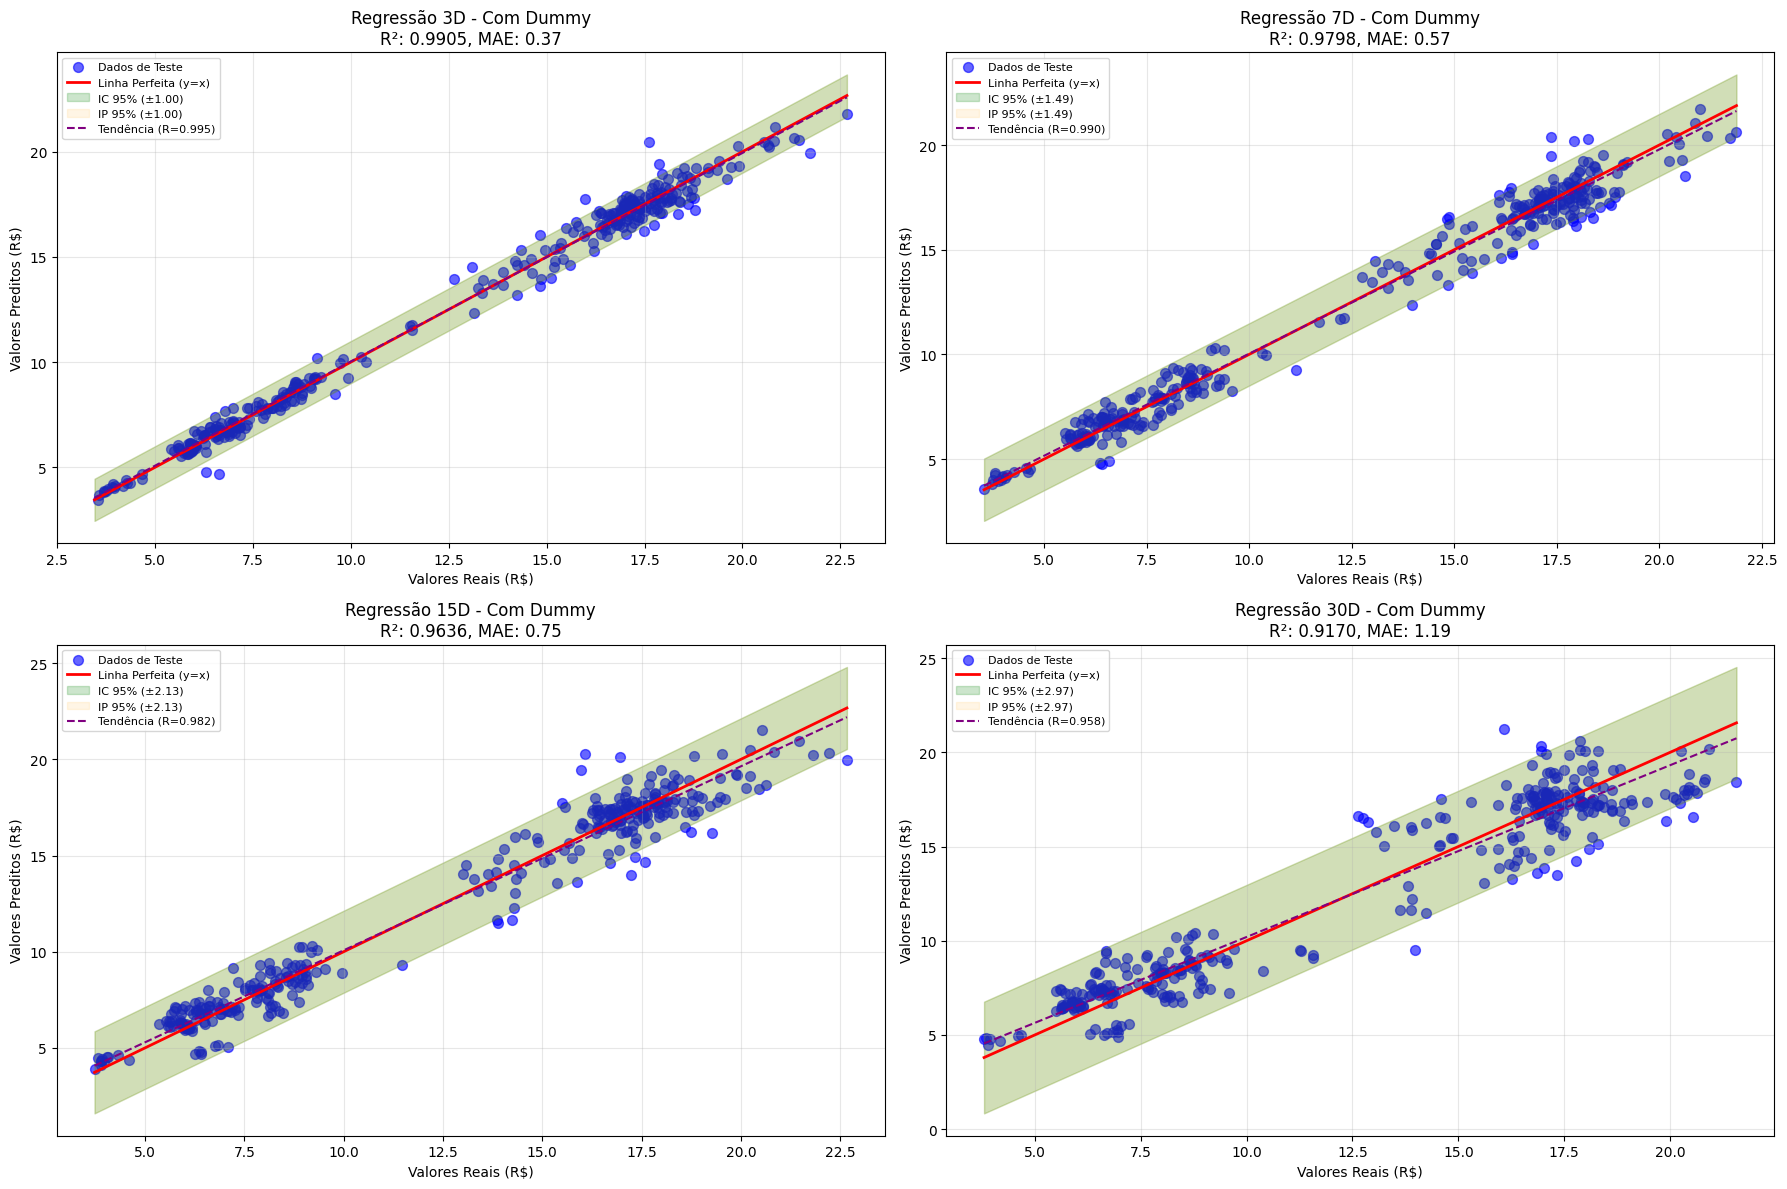

Gráficos de dispersão com IC e IP (modelos com dummy) gerados com sucesso!


In [28]:
# Gráficos de dispersão com linha de regressão, IC e IP para modelos com variáveis dummy
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models_with_dummy.items()):
    # Obter dados de teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_with_dummy, targets[period], test_size=0.2, random_state=42)
    
    # Predições
    y_pred_train = model_data['model'].predict(X_train)
    y_pred_test = model_data['model'].predict(X_test)
    
    # Calcular MSE e desvio padrão dos resíduos
    mse = mean_squared_error(y_train, y_pred_train)
    residual_std = np.sqrt(mse)
    
    # Plotar
    ax = axes[idx]
    
    # Scatter plot dos dados de teste
    ax.scatter(y_test, y_pred_test, alpha=0.6, color='blue', s=50, label='Dados de Teste')
    
    # Linha diagonal y=x (predição perfeita)
    min_val = min(y_test.min(), y_pred_test.min())
    max_val = max(y_test.max(), y_pred_test.max())
    line_vals = np.linspace(min_val, max_val, 100)
    ax.plot(line_vals, line_vals, 'r-', linewidth=2, label='Linha Perfeita (y=x)')
    
    # Intervalos de confiança (±1.96 * std para 95%)
    confidence_interval = 1.96 * residual_std
    ax.fill_between(line_vals, 
                    line_vals - confidence_interval, 
                    line_vals + confidence_interval, 
                    alpha=0.2, color='green', 
                    label=f'IC 95% (±{confidence_interval:.2f})')
    
    # Intervalos de predição (mais largos que IC)
    # Para regressão linear, IP ≈ IC * sqrt(1 + 1/n)
    n_samples = len(y_train)
    prediction_interval = confidence_interval * np.sqrt(1 + 1/n_samples)
    ax.fill_between(line_vals, 
                    line_vals - prediction_interval, 
                    line_vals + prediction_interval, 
                    alpha=0.1, color='orange', 
                    label=f'IP 95% (±{prediction_interval:.2f})')
    
    # Configurações do gráfico
    ax.set_title(f'Regressão {period.upper()} - Com Dummy\nR²: {model_data["r2"]:.4f}, MAE: {model_data["mae"]:.2f}')
    ax.set_xlabel('Valores Reais (R$)')
    ax.set_ylabel('Valores Preditos (R$)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Adicionar linha de tendência dos resíduos
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_pred_test)
    regression_line = slope * line_vals + intercept
    ax.plot(line_vals, regression_line, '--', color='purple', linewidth=1.5, 
            label=f'Tendência (R={r_value:.3f})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('dispersao_regressao_ic_ip_com_dummy.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráficos de dispersão com IC e IP (modelos com dummy) gerados com sucesso!")